In [2]:
library(Seurat)
library(data.table)
library(ggplot2)
library(ggpubr)
# library(ComplexHeatmap)
library(RColorBrewer)
library(circlize) # For colorRamp2
library(dplyr)
library(tidyr)
library(ggplot2)


In [3]:
scdata=readRDS("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step8.scdata_node_w_scores_pseudotime.rds")
scdata@meta.data[1:3,]

,sampleID,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,S.Score,G2M.Score,Phase,old.ident,mouse,⋯,MetGroup,scFitness,scPlasticity,scMetRate,Root_to_tip_distance,CytoTRACE2_Score,CytoTRACE2_Potency,CytoTRACE2_Relative,pseudotime,transition
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
C4007_LLT-1_AAACCCAAGGATTTGA-1,C4007_LLT-1,11995,4489,0.9670696,14.39767,-0.3777723,-0.34343502,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,Others,Others,Others,Others,0.114720450450392,Differentiated,0.114848463637216,Others,NA
C4007_LLT-1_AAACCCACACAACGAG-1,C4007_LLT-1,22160,6178,0.3925993,19.72473,-0.1619709,-0.27014986,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.140631295874457,0.512830249177513,0.00618598807275177,23.05455,0.10132772191846,Differentiated,0.101394697663774,0.42435199895567,ENT
C4007_LLT-1_AAACCCACAGGTCCCA-1,C4007_LLT-1,10826,4438,0.8220950,12.33142,0.3392319,-0.04680737,S,LLT-1,4007,⋯,MetGroup1:Primary-tropic,Others,Others,Others,Others,0.221428917730434,Unipotent,0.22204325540406,Others,ENT


# 1. phylovelo pseudotime

## 1) load rds, and split into ENT & NET

In [37]:
ent <- subset(scdata, transition=="ENT" & pseudotime !="Others")
net <- subset(scdata, transition=="NET" & pseudotime !="Others")
ent@meta.data$pseudotime <- as.numeric(ent@meta.data$pseudotime)
net@meta.data$pseudotime <- as.numeric(net@meta.data$pseudotime)
ent@meta.data[1:2,]
ent
net

,sampleID,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,S.Score,G2M.Score,Phase,old.ident,mouse,⋯,MetGroup,scFitness,scPlasticity,scMetRate,Root_to_tip_distance,CytoTRACE2_Score,CytoTRACE2_Potency,CytoTRACE2_Relative,pseudotime,transition
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
C4007_LLT-1_AAACCCACACAACGAG-1,C4007_LLT-1,22160,6178,0.3925993,19.72473,-0.1619709,-0.2701499,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.140631295874457,0.512830249177513,0.00618598807275177,23.05455,0.10132772191846,Differentiated,0.101394697663774,0.4243520,ENT
C4007_LLT-1_AAACCCAGTCGCACGT-1,C4007_LLT-1,19050,5655,0.7926509,15.98950,-0.2259478,-0.3126800,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.797562436889114,0.503530302621827,0.0044588882164829,14.1431,0.0735331411903948,Differentiated,0.0734734429654709,0.7095177,ENT


An object of class Seurat 
80613 features across 14195 samples within 2 assays 
Active assay: SCT (30047 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

An object of class Seurat 
80613 features across 13751 samples within 2 assays 
Active assay: SCT (30047 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

## 2) get TF list and orders

In [41]:
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.2.GRN/cluster_down_all")
cellAnnot <- read.csv("result1.cellAnnot.csv", row.names = 1, check.names = FALSE)
auc <- read.csv("result2.auc_mtx.csv", row.names = 1, check.names = FALSE)
rss <- read.csv("result3.rss_cellType.csv", row.names = 1, check.names = FALSE)
colnames(auc) <- gsub("\\(\\+\\)","",colnames(auc))
colnames(rss) <- gsub("\\(\\+\\)","",colnames(rss))
##########################################################
## step1. reform table to: ClusterID, Regulon, mean_auc, RSS
##########################################################
auc$CellID <- rownames(auc)
auc_annot <- left_join(auc, cellAnnot[, c("Celltype", "ClusterID")], by = c("CellID" = "Celltype"))

auc_long <- auc_annot %>%
  pivot_longer(
    cols = -c(CellID, ClusterID),
    names_to = "Regulon",
    values_to = "AUC"
  )
auc_summary <- auc_long %>%
  group_by(ClusterID, Regulon) %>%
  summarise(mean_auc = mean(AUC, na.rm = TRUE), .groups = "drop")
rss$ClusterID <- rownames(rss)
rss_long <- rss %>%
  pivot_longer(
    cols = -ClusterID,
    names_to = "Regulon",
    values_to = "RSS"
  )
final_table <- left_join(auc_summary, rss_long, by = c("ClusterID", "Regulon"))
final_table <- final_table %>%
  arrange(desc(RSS))
final_table[1:2,]
##########################################################
## scale mean_auc
final_table_scaled <- final_table %>%
  group_by(Regulon) %>%
  mutate(
    min_val = min(mean_auc, na.rm = TRUE),
    max_val = max(mean_auc, na.rm = TRUE),
    mean_auc_scaled = ifelse(
      min_val == max_val,
      0.5,
      (mean_auc - min_val) / (max_val - min_val)
    )
  ) %>%
  select(-min_val, -max_val) %>%
  ungroup()
final_table <- final_table_scaled
##########################################################
## step2. select interested genes
##########################################################
top10_list <- apply(rss, 1, function(x){names(sort(x, decreasing = TRUE)[2:11])})
top10_genes <- unique(as.character(unique(unlist(top10_list)))) 
print(length(top10_genes))
top10_N <- top10_list[,c(2,3,6)]                 
top10_E <- top10_list[,c(1,4,8,9)]                 
top10_Hybrid <- top10_list[,c(5,7)]

top10_genesN <- unique(as.character(unique(unlist(top10_N)))) 
top10_genesE <- unique(as.character(unique(unlist(top10_E)))) 
top10_genesHybrid <- unique(as.character(unique(unlist(top10_Hybrid)))) 
top10_genesHybrid <- top10_genesHybrid[(!top10_genesHybrid %in% top10_genesN) & (!top10_genesHybrid %in% top10_genesE)]

final_table_selected <- final_table[final_table$Regulon %in% c(top10_genesN,top10_genesE,top10_genesHybrid),]
regulon_orders <- unique(c(unique(final_table_selected$Regulon)[unique(final_table_selected$Regulon) %in% top10_genesE],
                   unique(final_table_selected$Regulon)[unique(final_table_selected$Regulon) %in% top10_genesHybrid],
                   unique(final_table_selected$Regulon)[unique(final_table_selected$Regulon) %in% top10_genesN]))
regulon_orders

ClusterID,Regulon,mean_auc,RSS
<chr>,<chr>,<dbl>,<dbl>
C2,E2f2,0.1625291,0.3797658
C2,Mxd3,0.4573696,0.3685862


[1] 41


[1] "Elf3"   "Zfp551" "Irf7"   "Atf3"   "Xbp1"   "Fos"    "Maff"   "Irf9"  
 [9] "Ets2"   "Junb"   "Fosb"   "Atf4"   "Jund"   "Rfx3"   "Ybx1"   "Jun"   
[17] "Zfp148" "Nfib"   "Klf7"   "Yy1"    "Sox9"   "E2f2"   "Mxd3"   "Zeb1"  
[25] "E2f7"   "Tcf7l2" "Zfp367" "Ctcf"   "Pbx1"   "Lcorl"  "Ilf2"   "Taf1"  
[33] "Bptf"   "Mycn"   "Rb1"    "Zfp704" "Elf2"   "Clock"  "Chd1"   "Tcf12" 
[41] "Zbtb20"

## 3) plot

In [42]:
options(repr.plot.width =8, repr.plot.height = 4) 
gene <- "Zeb1"
pdf(file ="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/phylovelo_pseudotime_regulon_TF_expression.pdf",width = 8.5,height = 3.5,onefile = TRUE)
for(gene in regulon_orders){
    ###################################################
    ## 1. ENT
    ###################################################
    df <- FetchData(ent, vars = c(gene, "pseudotime","harmony_cluster"))
    df$class <- ifelse(df$harmony_cluster %in% c(1,2,5),"N",
                      ifelse(df$harmony_cluster %in% c(0,3,7,8),"E","H"))
    df[[gene]]=df[[gene]]+0.1
    # df <- df[df[[gene]] > 0, ]
    p1 <- ggplot(df, aes(x = pseudotime, y = get(gene),color=pseudotime)) +#scale_y_log10()+
      geom_point(size = 0.5, alpha = 0.61) + scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +#scale_color_gradientn(colors = c("blue", "#D5D5D5FF", "red"))+
      geom_smooth(method = "loess", color = "red", se = FALSE) +theme_bw()+
      labs(x = "Pseudotime",y = paste(gene, "Expression"),title = "ENT") +
      theme(panel.grid =element_blank(),
            axis.text.x = element_text(size=12, colour = "black"),
            axis.text.y = element_text(size=12, colour = "black"),
            axis.title.x = element_text(size = 14),axis.title.y = element_text(size = 14),
           plot.title = element_text(size = 16,hjust = 0.5),
           legend.position="right")
    ###################################################
    ## 2. NET
    ###################################################
    df <- FetchData(net, vars = c(gene, "pseudotime","harmony_cluster"))
    df$class <- ifelse(df$harmony_cluster %in% c(1,2,5),"N",
                      ifelse(df$harmony_cluster %in% c(0,3,7,8),"E","H"))
    df[[gene]]=df[[gene]]+0.1
    p2 <- ggplot(df, aes(x = pseudotime, y = get(gene),color=pseudotime)) +#scale_y_log10()+
      geom_point(size = 0.5, alpha = 0.61) + scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +#scale_color_gradientn(colors = c("blue", "#D5D5D5FF", "red"))+
      geom_smooth(method = "loess", color = "red", se = FALSE) +theme_bw()+
      labs(x = "Pseudotime",y = paste(gene, "Expression"),title = "NET") +
      theme(panel.grid =element_blank(),
            axis.text.x = element_text(size=12, colour = "black"),
            axis.text.y = element_text(size=12, colour = "black"),
            axis.title.x = element_text(size = 14),axis.title.y = element_text(size = 14),
           plot.title = element_text(size = 16,hjust = 0.5),
           legend.position="right")
    print(ggarrange(p1,p2,ncol=2) )
}
dev.off()

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


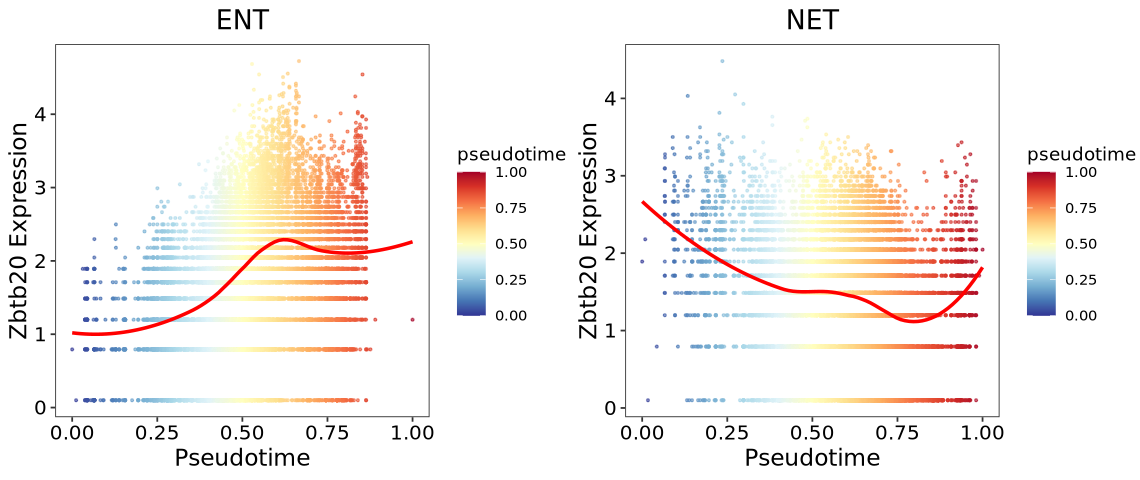

In [43]:
options(repr.plot.width =9.5, repr.plot.height = 4) 
ggarrange(p1,p2,ncol=2)

# 2. tradeSeq, 伪时间差异基因，heatmap

In [6]:
library(tradeSeq)
library(Seurat)
library(SingleCellExperiment)
library(ggplot2)
library(enrichR)
library(biomaRt)
library(stringr)
library(pheatmap)
library(dplyr)

# scdata <- readRDS("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step8.scdata_node_w_scores_pseudotime.rds")
# ent <- subset(scdata, transition=="ENT" & pseudotime !="Others")
# net <- subset(scdata, transition=="NET" & pseudotime !="Others")
# ent@meta.data$pseudotime <- as.numeric(ent@meta.data$pseudotime)
# net@meta.data$pseudotime <- as.numeric(net@meta.data$pseudotime)
# ent
# net

Welcome to enrichR
Checking connections ... 

Enrichr ... 
Connection is Live!

FlyEnrichr ... 
Connection is Live!

WormEnrichr ... 
Connection is Live!

YeastEnrichr ... 
Connection is Live!

FishEnrichr ... 
Connection is Live!

OxEnrichr ... 
Connection is Live!



Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.0 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%



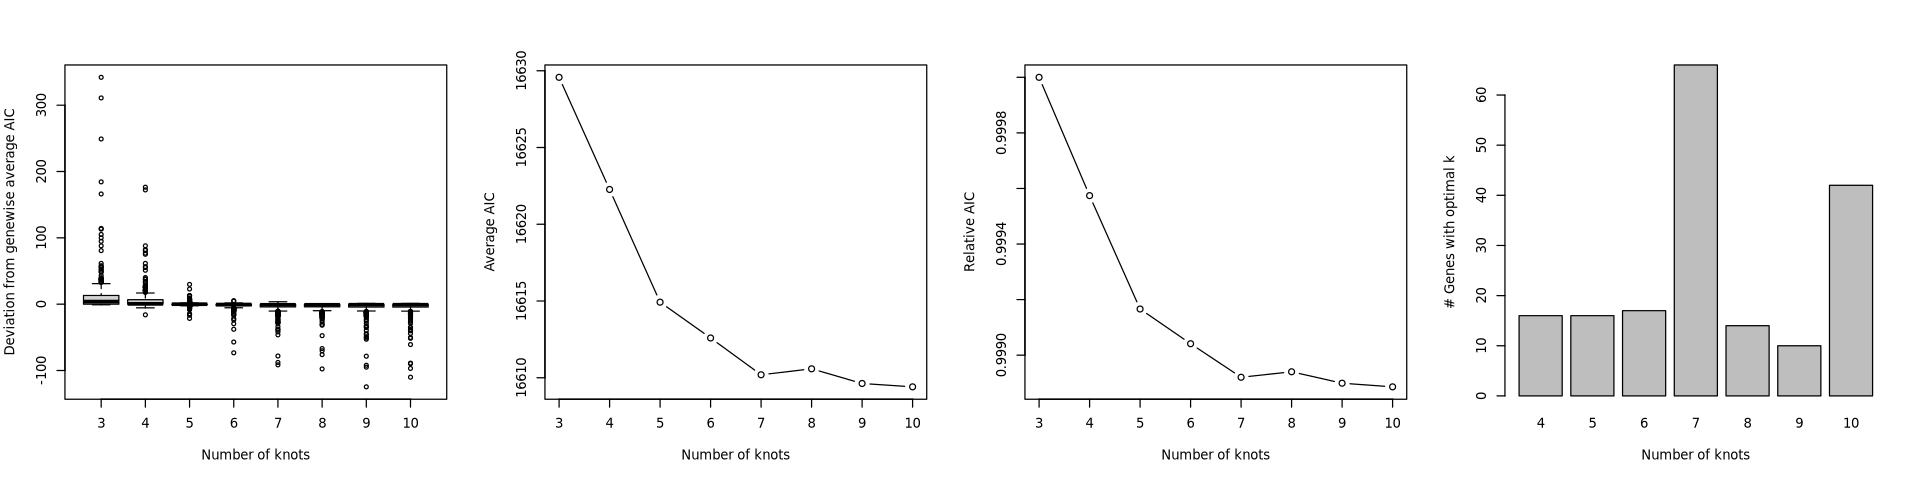

In [19]:
#####################################################################
## net
#####################################################################
counts <- GetAssayData(net, assay = "RNA", slot = "data")
keep_genes <- rowSums(counts > 0) >= 0.1 * ncol(counts)
counts_filtered <- counts[keep_genes, ]
pseudotime <- net@meta.data$pseudotime
names(pseudotime) <- colnames(net)
cellWeights <- matrix(1, nrow = length(pseudotime), ncol = 1)
rownames(cellWeights) <- colnames(net)
colnames(cellWeights) <- "curve1"
pseudotime_matrix <- matrix(pseudotime, ncol = 1)
rownames(pseudotime_matrix) <- colnames(net)
colnames(pseudotime_matrix) <- "curve1"
###############################################
# choose optimal K
set.seed(12345)
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers <- 30

options(repr.plot.width =16, repr.plot.height = 4) 
icMat <- evaluateK(counts = counts_filtered,pseudotime = pseudotime_matrix,
  cellWeights = cellWeights, k = 3:10, nGenes = 300, verbose = T, parallel=T, BPPARAM = BPPARAM) 

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.1 GiB”


  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%



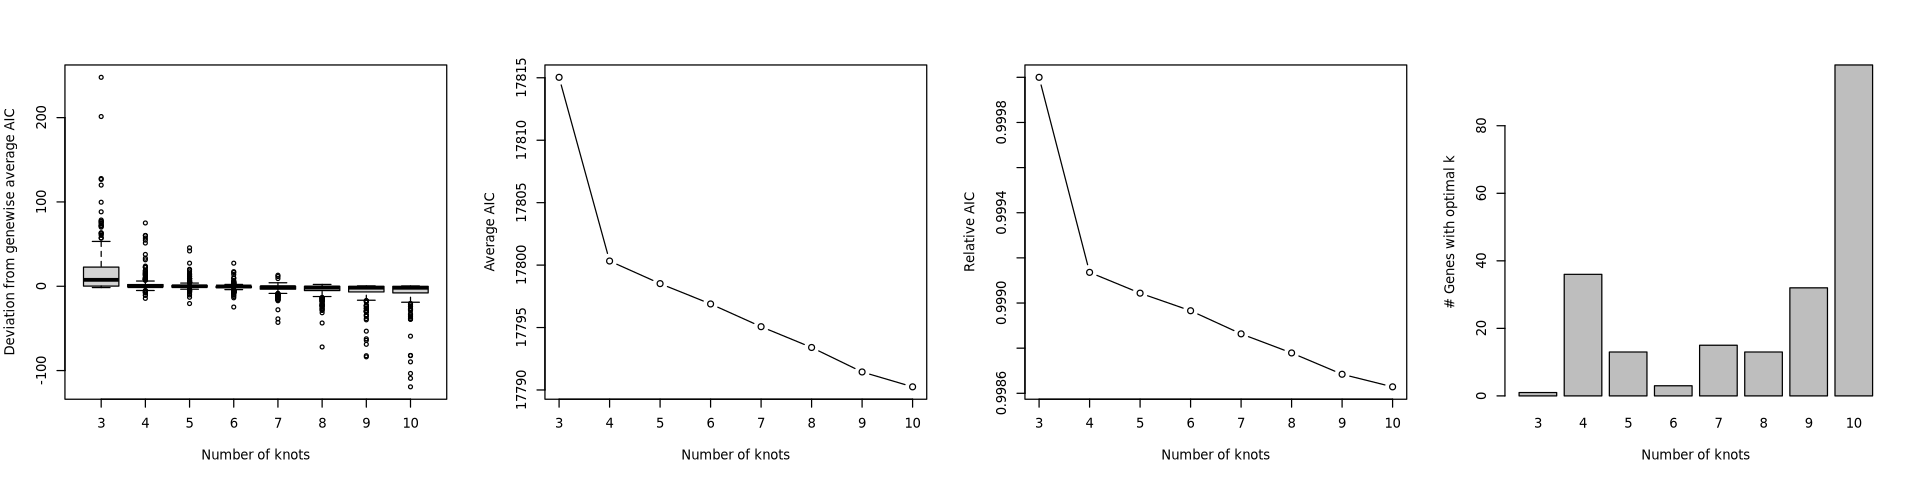

In [20]:
#####################################################################
## ent
#####################################################################
counts <- GetAssayData(ent, assay = "RNA", slot = "data")
keep_genes <- rowSums(counts > 0) >= 0.1 * ncol(counts)
counts_filtered <- counts[keep_genes, ]
pseudotime <- ent@meta.data$pseudotime
names(pseudotime) <- colnames(ent)
cellWeights <- matrix(1, nrow = length(pseudotime), ncol = 1)
rownames(cellWeights) <- colnames(ent)
colnames(cellWeights) <- "curve1"
pseudotime_matrix <- matrix(pseudotime, ncol = 1)
rownames(pseudotime_matrix) <- colnames(ent)
colnames(pseudotime_matrix) <- "curve1"
###############################################
# choose optimal K
set.seed(12345)
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers <- 30

options(repr.plot.width =16, repr.plot.height = 4) 
icMat <- evaluateK(counts = counts_filtered,pseudotime = pseudotime_matrix,
  cellWeights = cellWeights, k = 3:10, nGenes = 300, verbose = T, parallel=T, BPPARAM = BPPARAM) 

## 1) fitGAM

In [236]:
# fit NB models (# knots determined with the evaluateK procedure above)
set.seed(123)
gamModel <- fitGAM(
  counts = counts_filtered,
  pseudotime = pseudotime_matrix,
  cellWeights = cellWeights,
  nknots = 6,
  verbose = TRUE
)
saveRDS(gamModel,"/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/tradeSeq_out_gamModel_NET.rds")
assoRes <- associationTest(gamModel)
saveRDS(assoRes,"/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/tradeSeq_out_assoRes_NET.rds")
head(assoRes)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.8 GiB”


## 2) plot1, NET, knots=5,7

In [3]:
library(tradeSeq)
library(Seurat)
library(SingleCellExperiment)
library(ggplot2)
library(enrichR)
library(biomaRt)
library(stringr)
library(pheatmap)
library(dplyr)

### get smoothed

In [11]:
########################################
## load
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
gamModel1 <- readRDS("tradeSeq_out_gamModel_NET_7.rds")
assoRes1<- readRDS("tradeSeq_out_assoRes_NET_7.rds")
########################################
## filter
assoRes1 <- assoRes1[!is.na(assoRes1$waldStat),]
assoRes1['FDR'] = p.adjust(assoRes1$pvalue, method='fdr')
signif.genes1 <- rownames(assoRes1[which( (assoRes1$FDR < 0.05) & (assoRes1$meanLogFC > 0.5)),])
assoResSignif1 <- assoRes1[signif.genes1,]
########################################
## smooth
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
for (gene in rownames(assoResSignif1)) {
  ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 50)
  smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- signif.genes1
write.table(smoothed.profiles.lineage1,file="smoothed.profiles.lineage_NET_7.txt",sep="\t")

### cut clusters

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



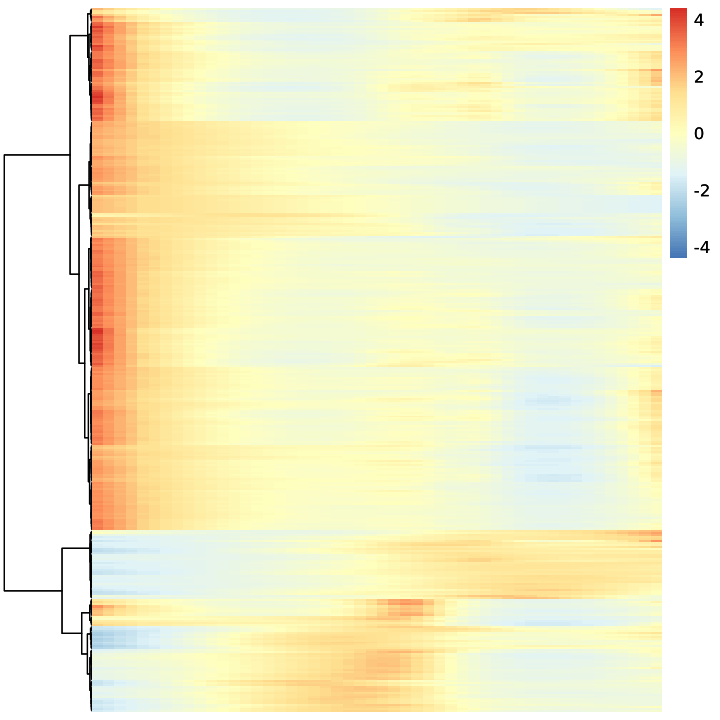

In [12]:
options(repr.plot.width =6, repr.plot.height = 6)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward',border_color = NA)
heatmap1

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



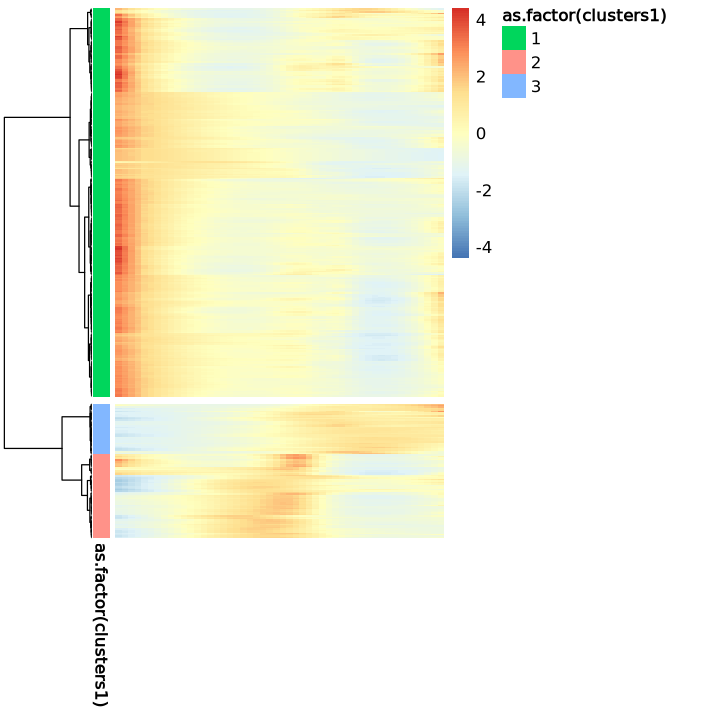

In [13]:
clusters1 = cutree(heatmap1$tree_row,k=3)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward', cutree_rows = 2,
                    annotation_row = as.data.frame(as.factor(clusters1)),border_color = NA)


### export DE genes

In [14]:
############################################################
## knots=6,6
############################################################
cluster_to_name = list("1"= "Stage1", "2" = "Stage2","3"= "Stage3")
assoResSignif1[,'Cluster'] = sapply(rownames(assoResSignif1), function(x) cluster_to_name[[clusters1[[x]]]])
WRITE = TRUE
write.table(assoResSignif1, "tradeseqDE_NET_7.tsv", sep='\t')

### plot marker gene heatmap

pdf 
  2

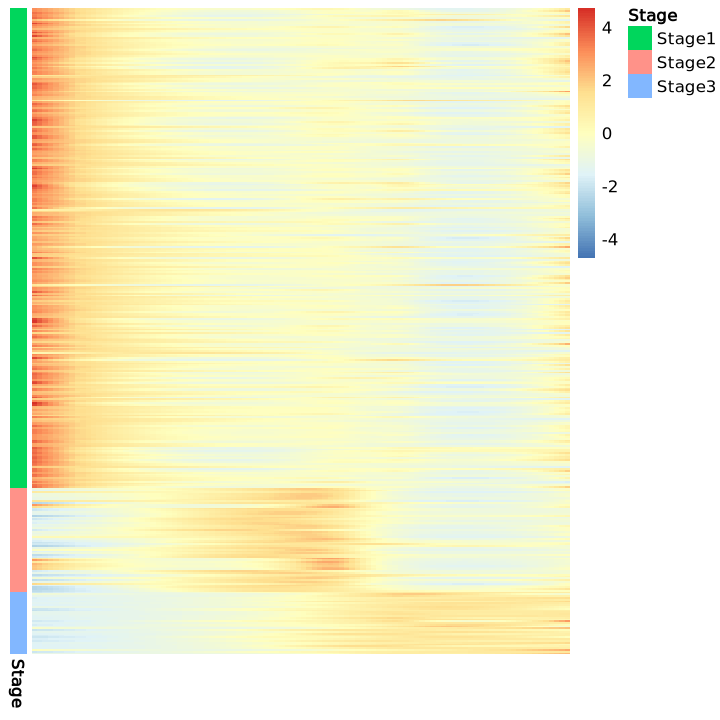

In [15]:
selected.genes = c(
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage1", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage2", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage3", ])
)

cluster.stage <- setNames(
  rep(c("Stage1", "Stage2", "Stage3"), #, "Stage4", "Stage5"
      times = c(
        sum(assoResSignif1$Cluster == "Stage1"),
        sum(assoResSignif1$Cluster == "Stage2"),
        sum(assoResSignif1$Cluster == "Stage3")
      )),
  selected.genes
)

# 预测平滑表达曲线
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
gene.names <- c()

for (gene in unique(selected.genes)) {
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
  }
}

smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

annotation_row <- data.frame(Stage = cluster.stage[gene.names])
rownames(annotation_row) <- gene.names

p <- pheatmap(smoothed.profiles.lineage1,
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         scale = 'row',
         show_rownames = FALSE,
         clustering_method = 'ward',
         #cutree_rows = 2,
         annotation_row = annotation_row,border_color = NA)
pdf(file ="Heatmap_DE_genes_NET_7.pdf",width = 5,height =6,onefile = TRUE)
p
dev.off()

## 3) plot2, ENT, knots=4,7

### get smoothed

In [21]:
########################################
## load
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
gamModel1 <- readRDS("tradeSeq_out_gamModel_ENT_7.rds")
assoRes1<- readRDS("tradeSeq_out_assoRes_ENT_7.rds")
########################################
## filter
assoRes1 <- assoRes1[!is.na(assoRes1$waldStat),]
assoRes1['FDR'] = p.adjust(assoRes1$pvalue, method='fdr')
signif.genes1 <- rownames(assoRes1[which( (assoRes1$FDR < 0.05) & (assoRes1$meanLogFC > 0.5)),])
assoResSignif1 <- assoRes1[signif.genes1,]
########################################
## smooth
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
for (gene in rownames(assoResSignif1)) {
  ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 50)
  smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- signif.genes1
write.table(smoothed.profiles.lineage1,file="smoothed.profiles.lineage_ENT_7.txt",sep="\t")

### cut clusters

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



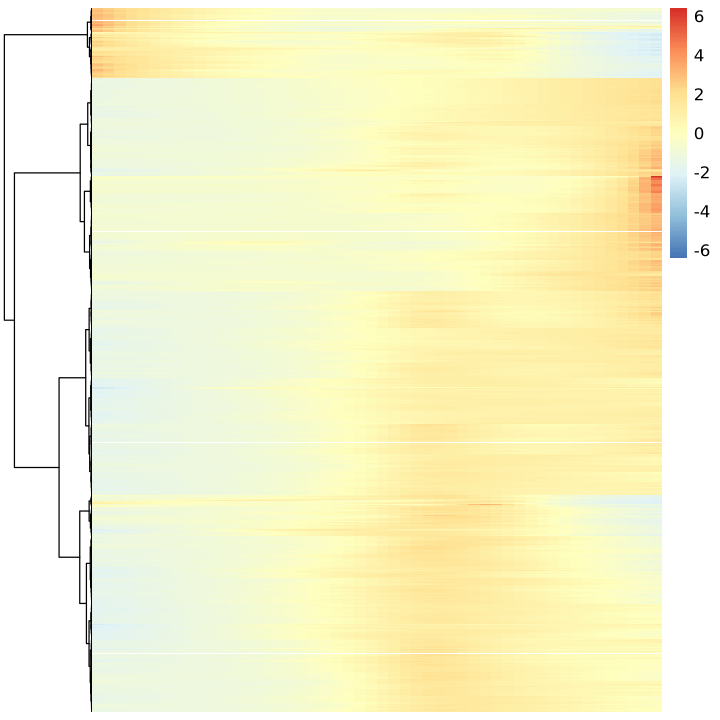

In [22]:
options(repr.plot.width =6, repr.plot.height = 6)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward',border_color = NA)

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



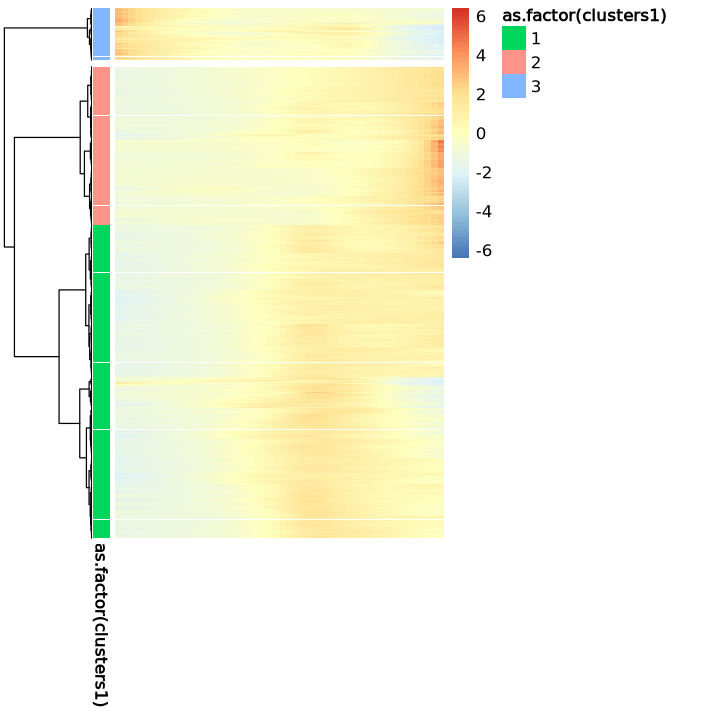

In [23]:
clusters1 = cutree(heatmap1$tree_row,k=3)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward', cutree_rows = 2,
                    annotation_row = as.data.frame(as.factor(clusters1)),border_color = NA)


### export DE genes

In [24]:
############################################################
## knots=6,6
############################################################
cluster_to_name = list("1"= "Stage2", "2" = "Stage3","3"= "Stage1")
assoResSignif1[,'Cluster'] = sapply(rownames(assoResSignif1), function(x) cluster_to_name[[clusters1[[x]]]])
WRITE = TRUE
write.table(assoResSignif1, "tradeseqDE_ENT_7.tsv", sep='\t')

### plot marker gene heatmap

pdf 
  2

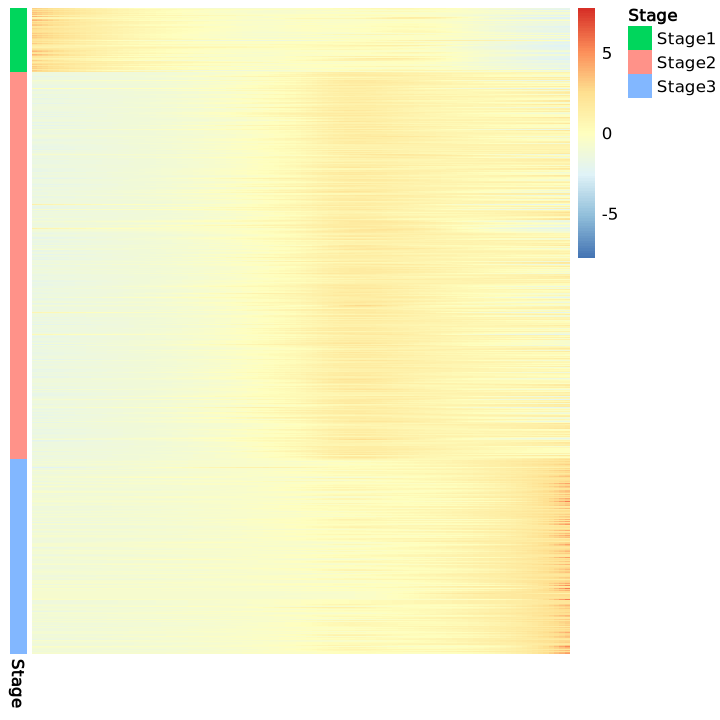

In [25]:
selected.genes = c(
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage1", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage2", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage3", ])
)

cluster.stage <- setNames(
  rep(c("Stage1", "Stage2", "Stage3"), #, "Stage4", "Stage5"
      times = c(
        sum(assoResSignif1$Cluster == "Stage1"),
        sum(assoResSignif1$Cluster == "Stage2"),
        sum(assoResSignif1$Cluster == "Stage3")
      )),
  selected.genes
)

# 预测平滑表达曲线
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
gene.names <- c()

for (gene in unique(selected.genes)) {
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
  }
}

smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

annotation_row <- data.frame(Stage = cluster.stage[gene.names])
rownames(annotation_row) <- gene.names

p <- pheatmap(smoothed.profiles.lineage1,
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         scale = 'row',
         show_rownames = FALSE,
         clustering_method = 'ward',
         cutree_rows = 2,
         annotation_row = annotation_row,border_color = NA)
pdf(file ="Heatmap_DE_genes_ENT_7.pdf",width = 5,height =6,onefile = TRUE)
p
dev.off()

## 4) plot SCENIC TFs

In [3]:
regulon_orders <- c("Elf3","Zfp551","Irf7","Atf3","Xbp1","Fos","Maff","Irf9","Ets2","Junb","Fosb","Atf4","Jund","Rfx3","Ybx1","Jun",
                    "Zfp148","Nfib","Klf7","Yy1","Sox9","E2f2","Mxd3",
                    "Zeb1","E2f7","Tcf7l2","Zfp367","Ctcf","Pbx1","Lcorl","Ilf2","Taf1","Bptf","Mycn","Zfp704","Elf2","Clock",
                    "Chd1","Tcf12","Zbtb20")

pdf 
  2

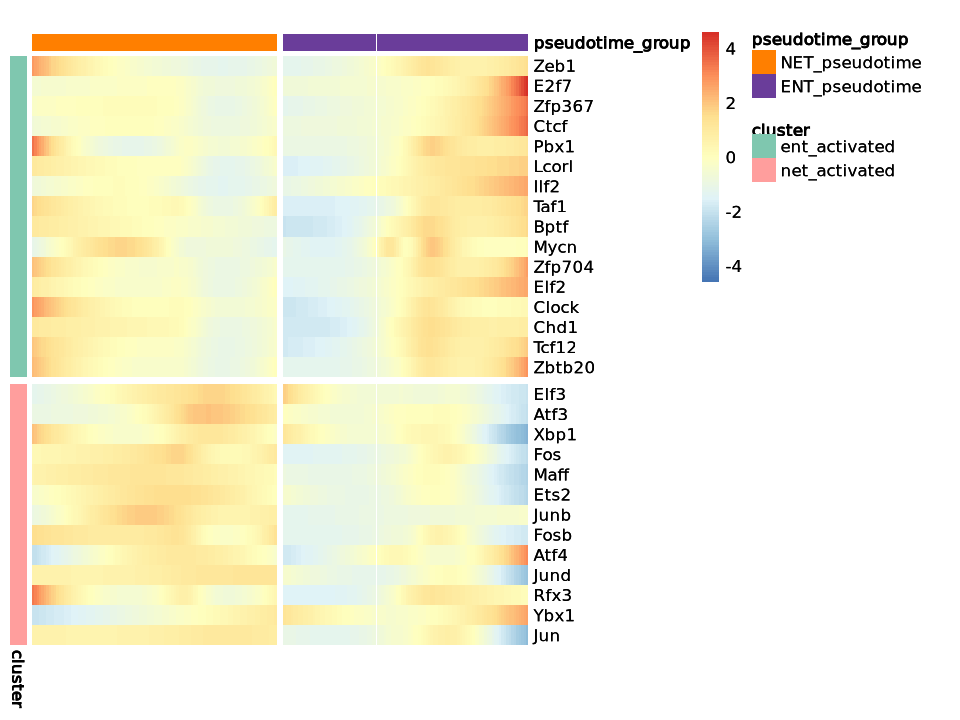

In [9]:
############ Plot marker gene heatmaps ########################
net.genes = regulon_orders[1:16]
hybrid.genes = regulon_orders[17:23]
ent.genes = regulon_orders[24:length(regulon_orders)]

setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
gamModel1 <- readRDS("tradeSeq_out_gamModel_NET_5.rds")
assoRes1<- readRDS("tradeSeq_out_assoRes_NET_5.rds")
assoResSignif1 <- read.delim("tradeseqDE_NET_5.tsv", header=T)

gamModel2 <- readRDS("tradeSeq_out_gamModel_ENT_7.rds")
assoRes2<- readRDS("tradeSeq_out_assoRes_ENT_7.rds")
assoResSignif2 <- read.delim("tradeseqDE_ENT_7.tsv", header=T)

smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))

gene.names <- c()
for (gene in unique(c(net.genes, ent.genes))) {#hybrid.genes, 
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

gene.names <- c()
for (gene in unique(c(net.genes, ent.genes))) {#hybrid.genes, 
  if (gene %in% rownames(gamModel2)) {
    ysmoothed = predictSmooth(models = gamModel2, gene = gene, nPoints = 100)
    smoothed.profiles.lineage2 = rbind(smoothed.profiles.lineage2, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage2 = smoothed.profiles.lineage2[-1,]
rownames(smoothed.profiles.lineage2) <- gene.names
###################################################################
## row annotations
fate.gene.annotations = data.frame(cluster = rep('Hybrid', length(hybrid.genes)))
rownames(fate.gene.annotations) <- hybrid.genes

uniq.net = net.genes[net.genes %in% rownames(smoothed.profiles.lineage1)]
hybrid.fate=hybrid.genes[hybrid.genes %in% rownames(smoothed.profiles.lineage1)]
uniq.ent = ent.genes[ent.genes %in% rownames(smoothed.profiles.lineage2)]
fate.gene.annotations = rbind(data.frame(cluster = rep('ent_activated', length(uniq.ent)), row.names=uniq.ent),
                              #data.frame(cluster = rep('hybrid', length(hybrid.fate)), row.names=hybrid.fate),
                              data.frame(cluster = rep('net_activated', length(uniq.net)), row.names=uniq.net))

###################################################################
## column annotations
annotation_col <- data.frame(
  pseudotime_group = c(rep("NET_pseudotime", 100),
                       rep("ENT_pseudotime", 100))
)
# rownames(annotation_col) <- colnames(total.smoothed.profiles)
# 自定义颜色（可选）  
ann_colors <- list(
  cluster = c(ent_activated = "#7FC7AFFF", net_activated = "#FF9E9DFF"),#hybrid = "#DAD8A7FF", 
  pseudotime_group = c(NET_pseudotime = "#ff7f00", ENT_pseudotime = "#6a3d9a")
)

total.smoothed.profiles = merge(smoothed.profiles.lineage1, smoothed.profiles.lineage2,by=0, all=TRUE)
total.smoothed.profiles[is.na(total.smoothed.profiles)] = 0
rownames(total.smoothed.profiles) <- total.smoothed.profiles$Row.names
total.smoothed.profiles <- total.smoothed.profiles[,-1]
rownames(annotation_col) <- colnames(total.smoothed.profiles)
heatmap.total = pheatmap(total.smoothed.profiles[rownames(fate.gene.annotations),], 
                         cluster_cols=F, cluster_rows=F, scale='row', show_rownames=T, clustering_method = 'ward', show_colnames = F,
                         annotation_row = fate.gene.annotations, annotation_col = annotation_col,annotation_colors = ann_colors,
                         main='', gaps_col=100, gaps_row=16)
options(repr.plot.width =8, repr.plot.height = 6)
heatmap.total

pdf(file ="Regulon_TF_heatmap_net5_ent7-2.pdf",width = 8,height =6,onefile = TRUE)
heatmap.total
dev.off()